Using existing file wandb_summary.csv
Number of valid runs: 72

===== Average performance per experiment (sorted by val/loss) =====
          run_name  val/loss  training_time_sec
G1_ternary_weights  1.474696         954.333333
    F1_context_128  1.503615         407.000000
         C1_1_head  1.523256         997.200000
A1_no_pos_encoding  1.570637         975.200000
        B2_post_ln  1.570879         941.400000
           D1_relu  1.607939         896.400000
        B1_rmsnorm  1.689924        1166.800000
E1_scaled_residual  1.689983         950.600000
          baseline  1.699641         931.600000
        C2_8_heads  1.709375         967.200000
       C3_12_heads  1.716220         975.400000
           A2_rope  1.746490        1100.000000
          A3_alibi  1.813703        1673.600000
         D2_swiglu  1.879844        1018.400000
    F2_context_512  2.012419        1841.666667
   E2_no_residuals  3.357969         801.333333


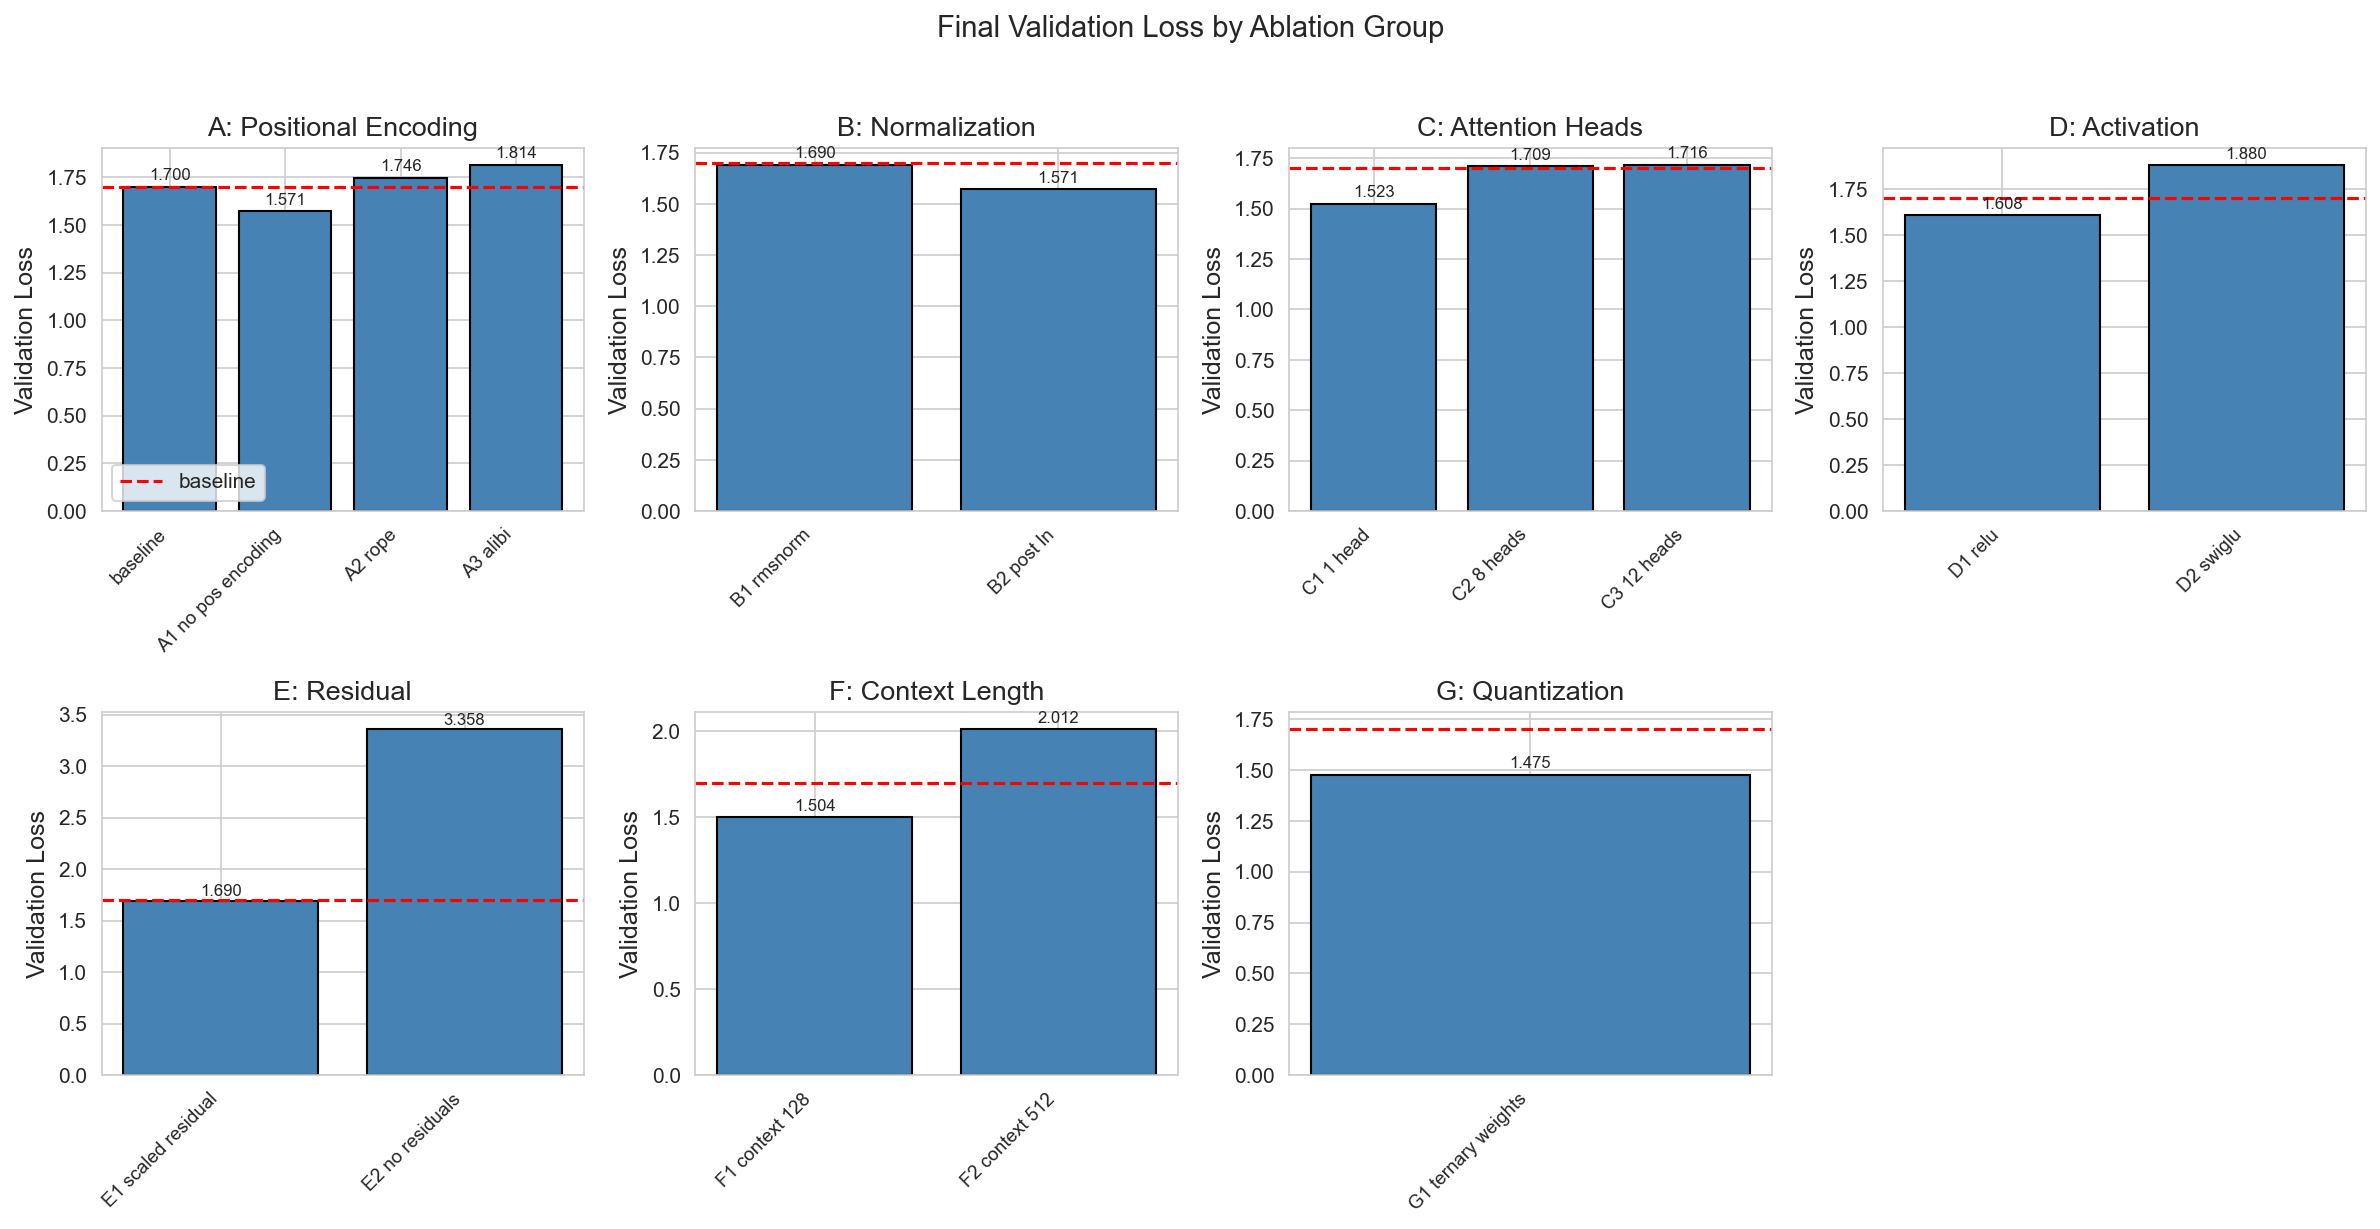

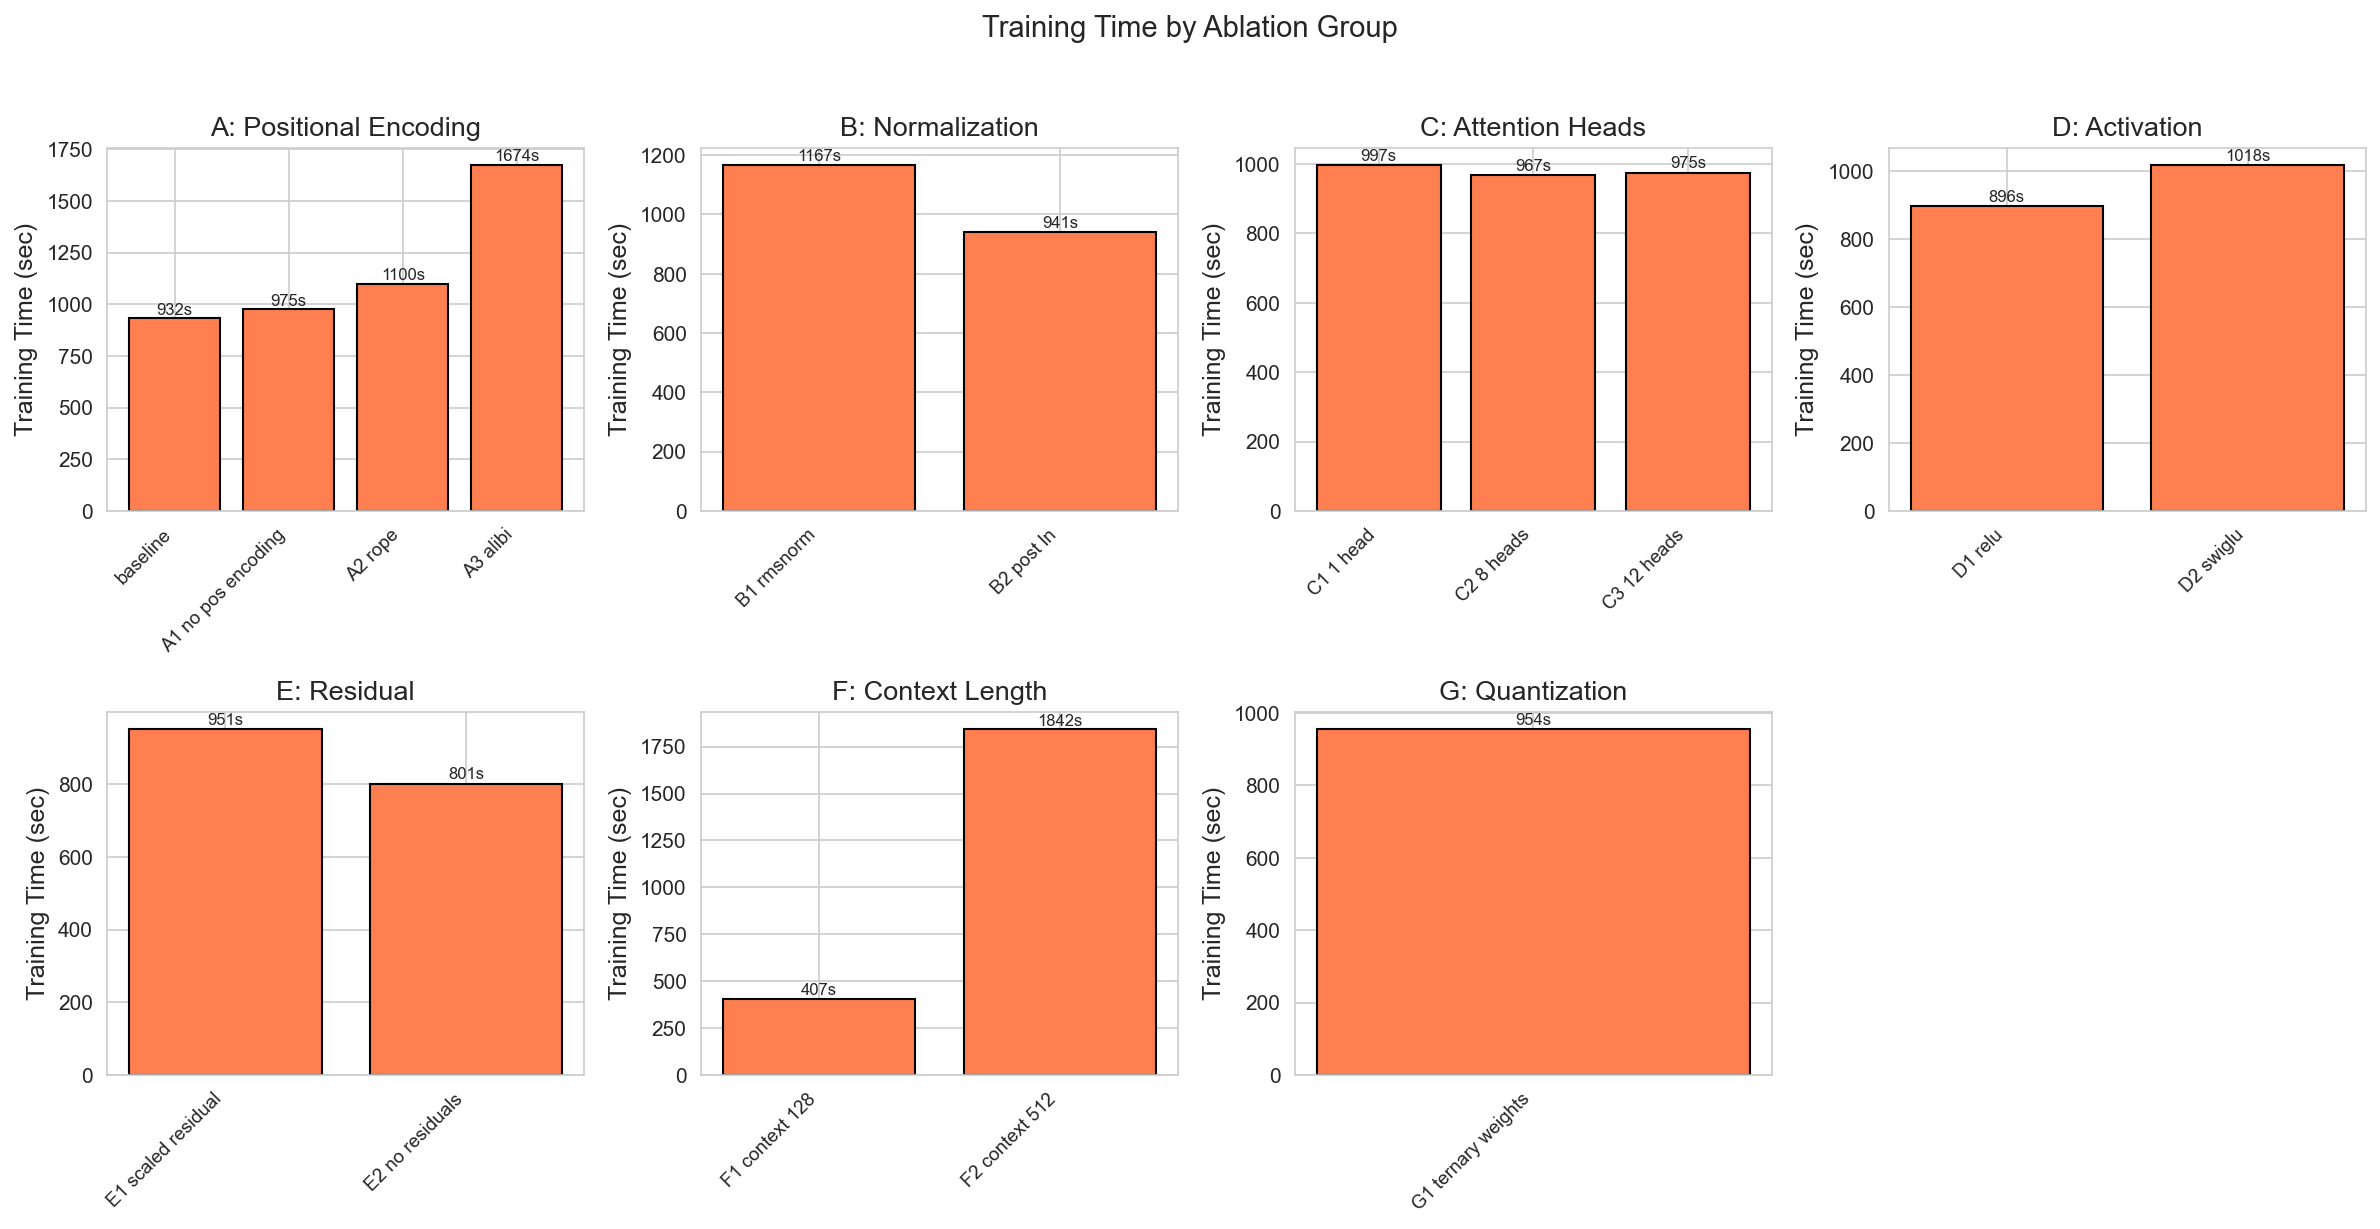

Plotted baseline: 21 points
Plotted A1_no_pos_encoding: 21 points
Plotted E2_no_residuals: 21 points
Plotted G1_ternary_weights: 21 points


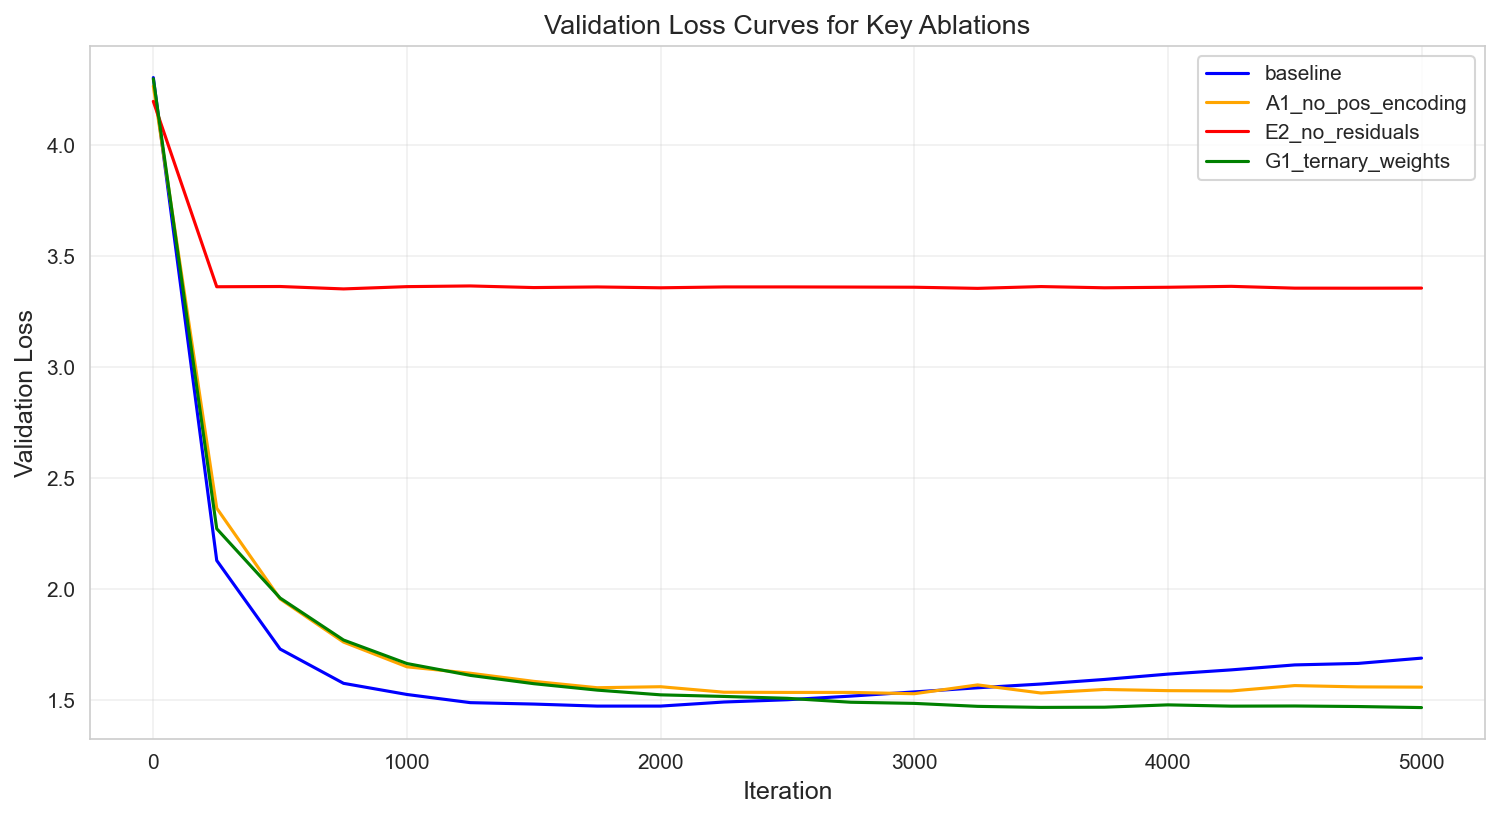

Saved validation loss plot to analysis_figures/learning_curves.png


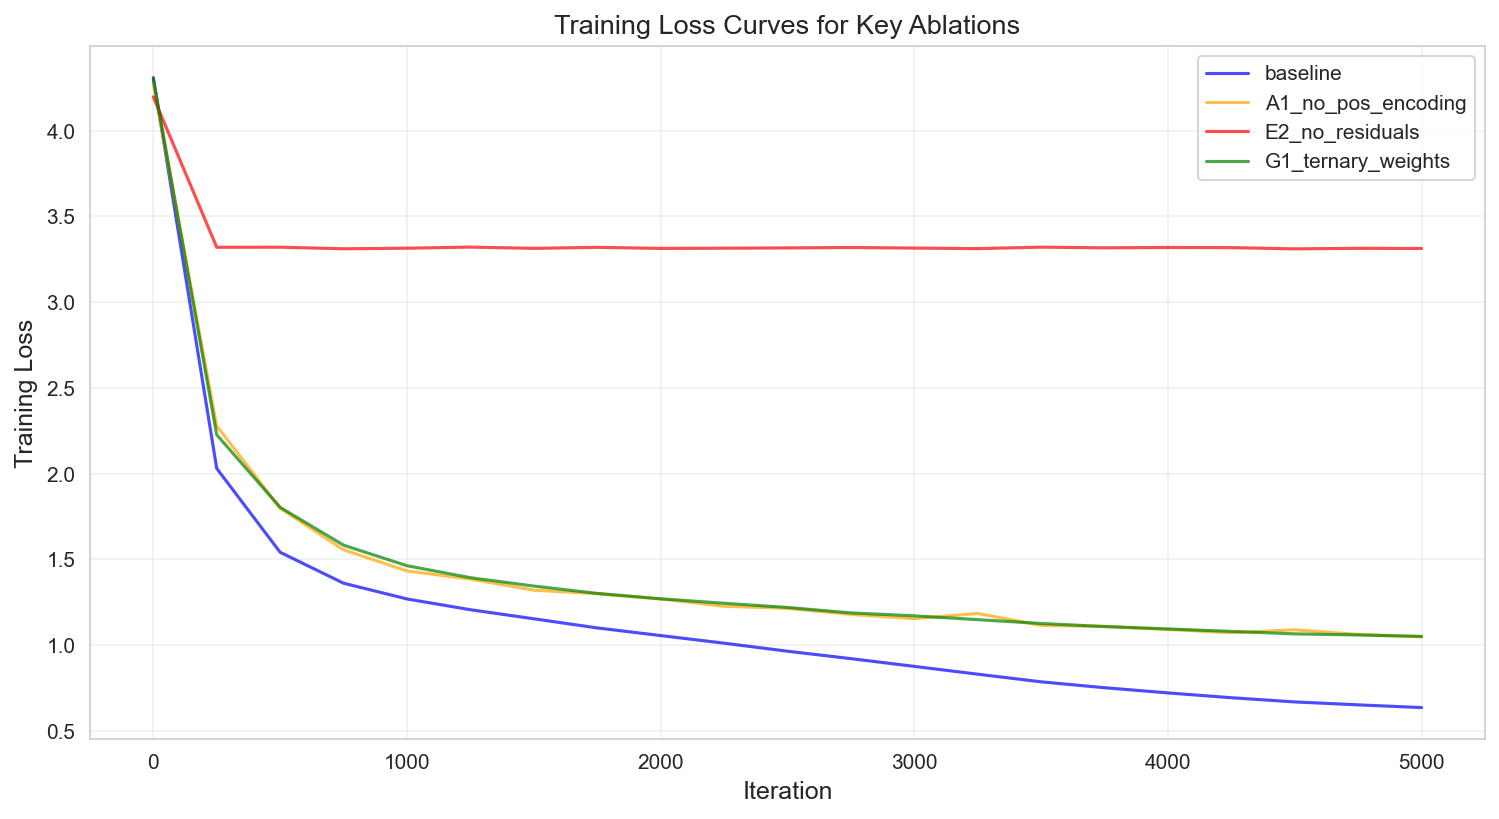

Saved training loss plot to analysis_figures/train_curves.png

Summary table saved to analysis_figures\summary_table.csv
                 Group      Configuration  Val Loss  Δ from baseline  Training Time (s)  Params (M)
A: Positional Encoding A1 no pos encoding    1.5706          -0.1290              975.2       10.65
A: Positional Encoding            A2 rope    1.7465           0.0468             1100.0       10.65
A: Positional Encoding           A3 alibi    1.8137           0.1141             1673.6       10.65
A: Positional Encoding           baseline    1.6996           0.0000              931.6       10.75
      B: Normalization         B1 rmsnorm    1.6899          -0.0097             1166.8       10.75
      B: Normalization         B2 post ln    1.5709          -0.1288              941.4       10.75
    C: Attention Heads          C1 1 head    1.5233          -0.1764              997.2       10.75
    C: Attention Heads         C2 8 heads    1.7094           0.0097           

In [14]:
#!/usr/bin/env python
# coding: utf-8

# ==================================================
# Complete Experiment Results Analysis Script (Revised)
# Features:
#   1. Fetch all run summaries from wandb (keep _runtime as training time)
#   2. Clean data, compute mean per run_name
#   3. Generate final validation loss and training time comparison plots
#   4. Plot learning curves for key ablations
#   5. Export summary table to CSV
# ==================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

# ----- Configuration -----
ENTITY = "madhavkrishnan747-australian-national-university"
PROJECT = "nanogpt-ablations"
SUMMARY_CSV = "wandb_summary.csv"      # local cache
OUTPUT_DIR = "analysis_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 150

# ==================================================
# 1. Fetch or load summary data from wandb (keep _runtime)
# ==================================================
def fetch_or_load_summary(force_refresh=False):
    """Load cached summary CSV or fetch fresh data from wandb."""
    if not force_refresh and os.path.exists(SUMMARY_CSV):
        print(f"Using existing file {SUMMARY_CSV}")
        df = pd.read_csv(SUMMARY_CSV)
        return df
    
    print("Fetching data from wandb...")
    api = wandb.Api()
    runs = api.runs(f"{ENTITY}/{PROJECT}")
    records = []
    for run in runs:
        # Keep all summary fields (including _runtime)
        summary = dict(run.summary)
        # Get config (ignore fields starting with '_')
        config = {k: v for k, v in run.config.items() if not k.startswith('_')}
        # Merge
        record = {
            'run_name': run.name,
            'run_id': run.id,
            'state': run.state,
            'created_at': run.created_at,
            'url': run.url,
            **config,
            **summary
        }
        records.append(record)
    
    df = pd.DataFrame(records)
    # Rename _runtime to training_time_sec if present
    if '_runtime' in df.columns:
        df['training_time_sec'] = df['_runtime']
    elif 'training_time_sec' not in df.columns:
        df['training_time_sec'] = np.nan
    df.to_csv(SUMMARY_CSV, index=False)
    print(f"Saved to {SUMMARY_CSV}")
    return df

df_all = fetch_or_load_summary(force_refresh=False)   # Set True to force refresh

# ----- Data cleaning: keep only finished runs with iter==5000 and non-null training time -----
df_valid = df_all[(df_all['state'] == 'finished') & (df_all['iter'] == 5000) & (df_all['training_time_sec'].notna())].copy()
print(f"Number of valid runs: {len(df_valid)}")

# If there are duplicate run_name (different seeds), take mean per run_name
df_mean = df_valid.groupby('run_name').agg({
    'val/loss': 'mean',
    'train/loss': 'mean',
    'training_time_sec': 'mean',
    'n_params': 'first'
}).reset_index()

print("\n===== Average performance per experiment (sorted by val/loss) =====")
df_sorted = df_mean.sort_values('val/loss')
print(df_sorted[['run_name', 'val/loss', 'training_time_sec']].to_string(index=False))

# ==================================================
# 2. Define ablation groups
# ==================================================
group_mapping = {
    'baseline': 'A: Positional Encoding',
    'A1_no_pos_encoding': 'A: Positional Encoding',
    'A2_rope': 'A: Positional Encoding',
    'A3_alibi': 'A: Positional Encoding',
    'B1_rmsnorm': 'B: Normalization',
    'B2_post_ln': 'B: Normalization',
    'C1_1_head': 'C: Attention Heads',
    'C2_8_heads': 'C: Attention Heads',
    'C3_12_heads': 'C: Attention Heads',
    'D1_relu': 'D: Activation',
    'D2_swiglu': 'D: Activation',
    'E1_scaled_residual': 'E: Residual',
    'E2_no_residuals': 'E: Residual',
    'F1_context_128': 'F: Context Length',
    'F2_context_512': 'F: Context Length',
    'G1_ternary_weights': 'G: Quantization'
}

df_mean['group'] = df_mean['run_name'].map(group_mapping)
df_mean['short_name'] = df_mean['run_name'].str.replace('_', ' ')

# ==================================================
# 3. Plot final validation loss (faceted by group)
# ==================================================
order_dict = {
    'A: Positional Encoding': ['baseline', 'A1_no_pos_encoding', 'A2_rope', 'A3_alibi'],
    'B: Normalization': ['baseline', 'B1_rmsnorm', 'B2_post_ln'],
    'C: Attention Heads': ['baseline', 'C1_1_head', 'C2_8_heads', 'C3_12_heads'],
    'D: Activation': ['baseline', 'D1_relu', 'D2_swiglu'],
    'E: Residual': ['baseline', 'E1_scaled_residual', 'E2_no_residuals'],
    'F: Context Length': ['baseline', 'F1_context_128', 'F2_context_512'],
    'G: Quantization': ['baseline', 'G1_ternary_weights']
}

groups = df_mean['group'].dropna().unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

baseline_val = df_mean[df_mean['run_name']=='baseline']['val/loss'].values[0]

for idx, group_name in enumerate(sorted(groups)):
    ax = axes[idx]
    subset = df_mean[df_mean['group'] == group_name].copy()
    ordered_names = order_dict.get(group_name, subset['run_name'].unique())
    subset['order'] = subset['run_name'].map({name: i for i, name in enumerate(ordered_names)})
    subset = subset.sort_values('order')
    
    x = range(len(subset))
    bars = ax.bar(x, subset['val/loss'], color='steelblue', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(subset['short_name'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Validation Loss')
    ax.set_title(group_name)
    ax.axhline(y=baseline_val, color='red', linestyle='--', label='baseline')
    for bar, val in zip(bars, subset['val/loss']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    if idx == 0:
        ax.legend()

for idx in range(len(groups), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Final Validation Loss by Ablation Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'val_loss_by_group.png'), bbox_inches='tight')
plt.show()

# ==================================================
# 4. Plot training time (faceted by group)
# ==================================================
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
axes2 = axes2.flatten()

for idx, group_name in enumerate(sorted(groups)):
    ax = axes2[idx]
    subset = df_mean[df_mean['group'] == group_name].copy()
    ordered_names = order_dict.get(group_name, subset['run_name'].unique())
    subset['order'] = subset['run_name'].map({name: i for i, name in enumerate(ordered_names)})
    subset = subset.sort_values('order')
    
    x = range(len(subset))
    bars = ax.bar(x, subset['training_time_sec'], color='coral', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(subset['short_name'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Training Time (sec)')
    ax.set_title(group_name)
    for bar, val in zip(bars, subset['training_time_sec']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{val:.0f}s', ha='center', va='bottom', fontsize=8)

for idx in range(len(groups), len(axes2)):
    axes2[idx].axis('off')

plt.suptitle('Training Time by Ablation Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'time_by_group.png'), bbox_inches='tight')
plt.show()

# ==================================================
# 5. Learning curves for key experiments (download from wandb)
# ==================================================
# ==================================================
# SAFE PLOT: Validation Loss Curves
# ==================================================
import matplotlib.pyplot as plt

# Check if we have data
if len(history_dict) == 0:
    print("No history data available. Skipping plots.")
else:
    # Plot validation loss
    plt.figure(figsize=(12, 6))
    colors = {'baseline': 'blue', 'A1_no_pos_encoding': 'orange', 
              'E2_no_residuals': 'red', 'G1_ternary_weights': 'green'}
    
    for name, hist in history_dict.items():
        if 'val/loss' in hist.columns and 'iter' in hist.columns:
            # Ensure data is numeric and drop NaN
            valid_mask = hist['val/loss'].notna() & hist['iter'].notna()
            x = hist.loc[valid_mask, 'iter'].values
            y = hist.loc[valid_mask, 'val/loss'].values
            if len(x) > 0:
                plt.plot(x, y, label=name, color=colors.get(name, 'black'), linewidth=1.5)
                print(f"Plotted {name}: {len(x)} points")
            else:
                print(f"Warning: No valid points for {name}")
        else:
            print(f"Missing columns for {name}: has val/loss={'val/loss' in hist.columns}, has iter={'iter' in hist.columns}")
    
    plt.xlabel('Iteration')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss Curves for Key Ablations')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved validation loss plot to {OUTPUT_DIR}/learning_curves.png")
    
    # Plot training loss
    plt.figure(figsize=(12, 6))
    for name, hist in history_dict.items():
        if 'train/loss' in hist.columns and 'iter' in hist.columns:
            valid_mask = hist['train/loss'].notna() & hist['iter'].notna()
            x = hist.loc[valid_mask, 'iter'].values
            y = hist.loc[valid_mask, 'train/loss'].values
            if len(x) > 0:
                plt.plot(x, y, label=name, color=colors.get(name, 'black'), alpha=0.7, linewidth=1.5)
            else:
                print(f"Warning: No valid training points for {name}")
        else:
            print(f"Missing training columns for {name}")
    
    plt.xlabel('Iteration')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Curves for Key Ablations')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'train_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved training loss plot to {OUTPUT_DIR}/train_curves.png")

# ==================================================
# 6. Generate summary table
# ==================================================
summary_stats = []
for group_name in sorted(groups):
    subset = df_mean[df_mean['group'] == group_name]
    for _, row in subset.iterrows():
        summary_stats.append({
            'Group': group_name,
            'Configuration': row['short_name'],
            'Val Loss': round(row['val/loss'], 4),
            'Δ from baseline': round(row['val/loss'] - baseline_val, 4),
            'Training Time (s)': round(row['training_time_sec'], 1),
            'Params (M)': round(row['n_params'] / 1e6, 2)
        })

df_summary_table = pd.DataFrame(summary_stats)
df_summary_table.to_csv(os.path.join(OUTPUT_DIR, 'summary_table.csv'), index=False)
print("\nSummary table saved to", os.path.join(OUTPUT_DIR, 'summary_table.csv'))
print(df_summary_table.to_string(index=False))

# ==================================================
# 7. Print key findings
# ==================================================
print("\n" + "="*60)
print("Key Findings (based on mean validation loss):")
print("="*60)

best = df_mean.loc[df_mean['val/loss'].idxmin()]
worst = df_mean.loc[df_mean['val/loss'].idxmax()]
print(f"Best configuration: {best['run_name']}  val_loss = {best['val/loss']:.4f}")
print(f"Worst configuration: {worst['run_name']}  val_loss = {worst['val/loss']:.4f}")

no_res = df_mean[df_mean['run_name']=='E2_no_residuals']['val/loss'].values
if len(no_res) > 0:
    print(f"Removing residual connections caused validation loss to skyrocket to {no_res[0]:.2f} (baseline: {baseline_val:.2f}), training fails.")

pos_enc = df_mean[df_mean['run_name'].isin(['A1_no_pos_encoding', 'A2_rope', 'A3_alibi'])]
print("\nPositional encoding comparison:")
for _, row in pos_enc.iterrows():
    print(f"  {row['run_name']}: val_loss = {row['val/loss']:.4f}")

print(f"\nAll figures and tables saved to {OUTPUT_DIR} folder.")

In [15]:
import os
import wandb
import re
from bs4 import BeautifulSoup  # If not installed, run: pip install beautifulsoup4

# Configuration
ENTITY = "madhavkrishnan747-australian-national-university"
PROJECT = "nanogpt-ablations"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# List of run names to download samples for (can be extended as needed)
target_runs = ['baseline', 'A1_no_pos_encoding', 'E2_no_residuals', 'G1_ternary_weights']

api = wandb.Api()

for run_name in target_runs:
    # Get the latest finished run with this name
    runs = api.runs(f"{ENTITY}/{PROJECT}", filters={"display_name": run_name, "state": "finished"})
    if len(runs) == 0:
        print(f"Run {run_name} not found")
        continue
    run = sorted(runs, key=lambda r: r.created_at, reverse=True)[0]
    
    # Find sample generation files
    sample_files = [f for f in run.files() if f.name.startswith("media/html/Sample Generation")]
    if not sample_files:
        print(f"{run_name} has no sample generation file")
        continue
    # Take the first one (usually only one)
    sample_file = sample_files[0]
    # Download to a temporary directory
    sample_file.download(root=".wandb_tmp", replace=True)
    local_path = os.path.join(".wandb_tmp", sample_file.name)
    
    # Read HTML and extract text (assuming text is inside a <pre> tag)
    with open(local_path, 'r', encoding='utf-8') as f:
        html = f.read()
    soup = BeautifulSoup(html, 'html.parser')
    pre_tag = soup.find('pre')
    if pre_tag:
        text = pre_tag.get_text()
    else:
        # If no <pre> tag, try to get the entire body text
        text = soup.get_text()
    
    # Save to output folder
    output_path = os.path.join(OUTPUT_DIR, f"{run_name}_sample.txt")
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(f"--- Model: {run_name} ---\n")
        f.write(f"--- Run ID: {run.id} ---\n\n")
        f.write(text)
    print(f"Saved {output_path}")
    
    # Clean up temporary file
    os.remove(local_path)

# Delete temporary directory if empty
try:
    os.rmdir(".wandb_tmp")
except:
    pass

Saved output\baseline_sample.txt
Saved output\A1_no_pos_encoding_sample.txt
Saved output\E2_no_residuals_sample.txt
Saved output\G1_ternary_weights_sample.txt


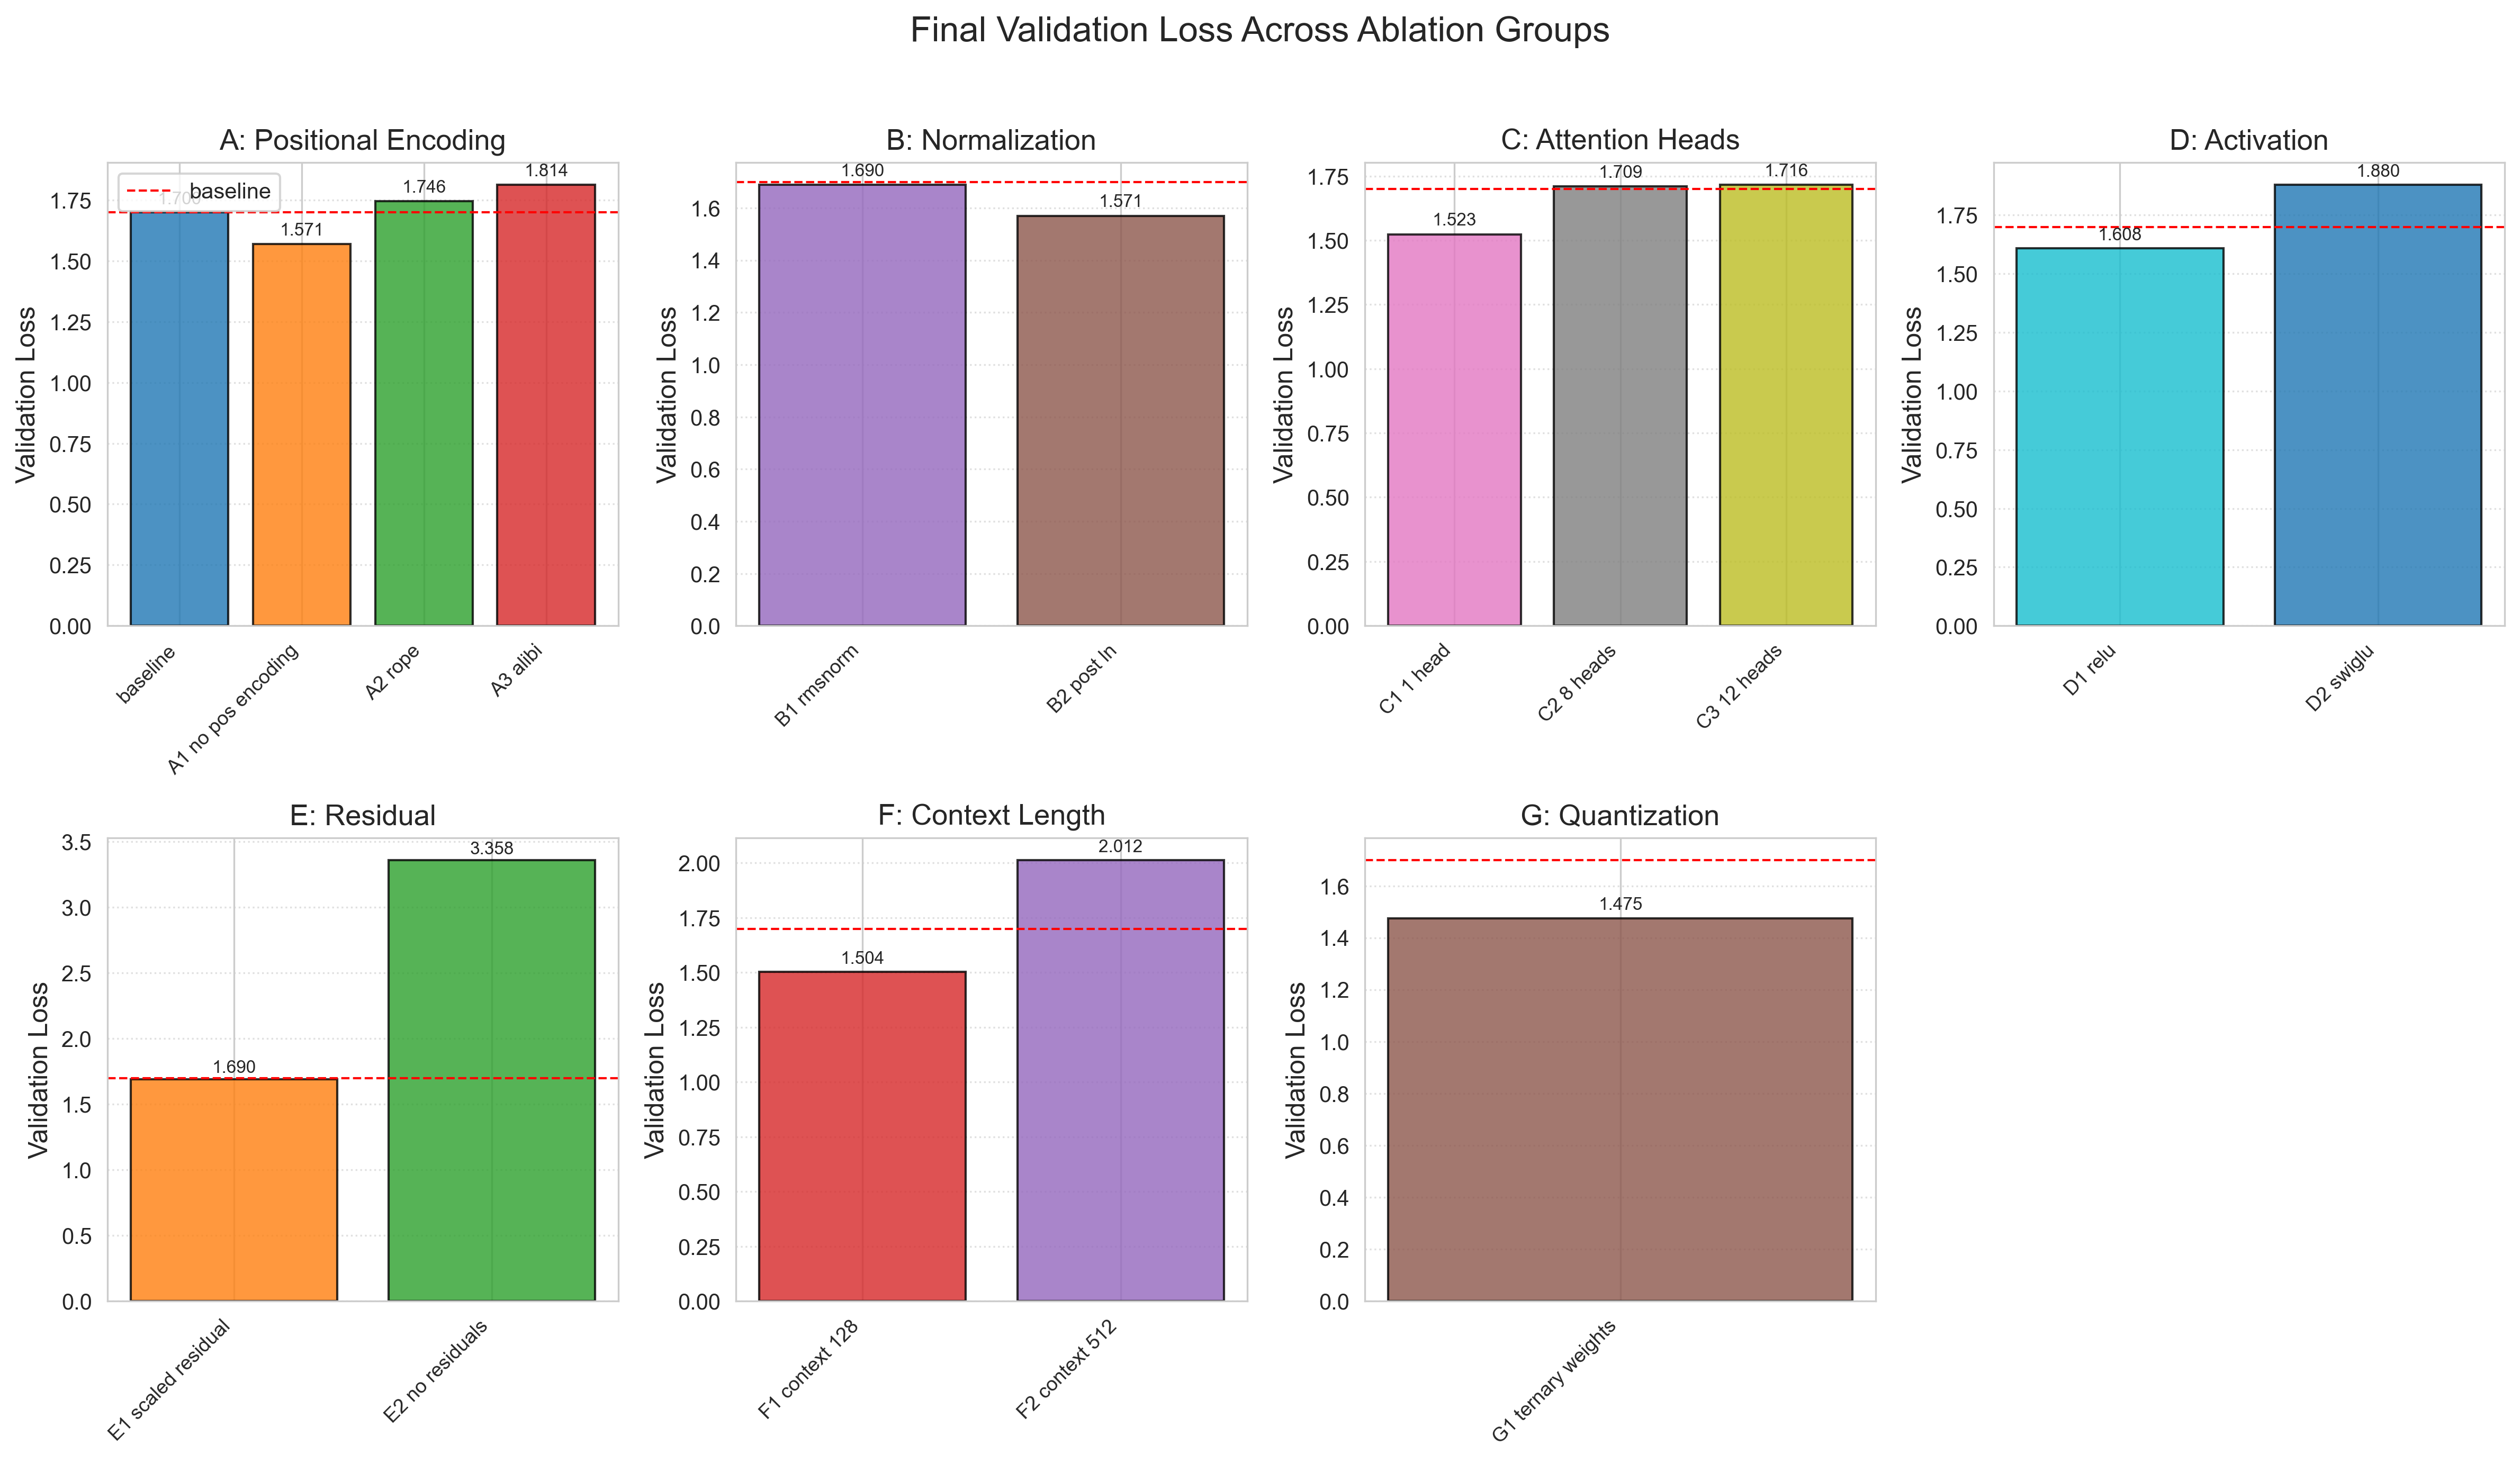

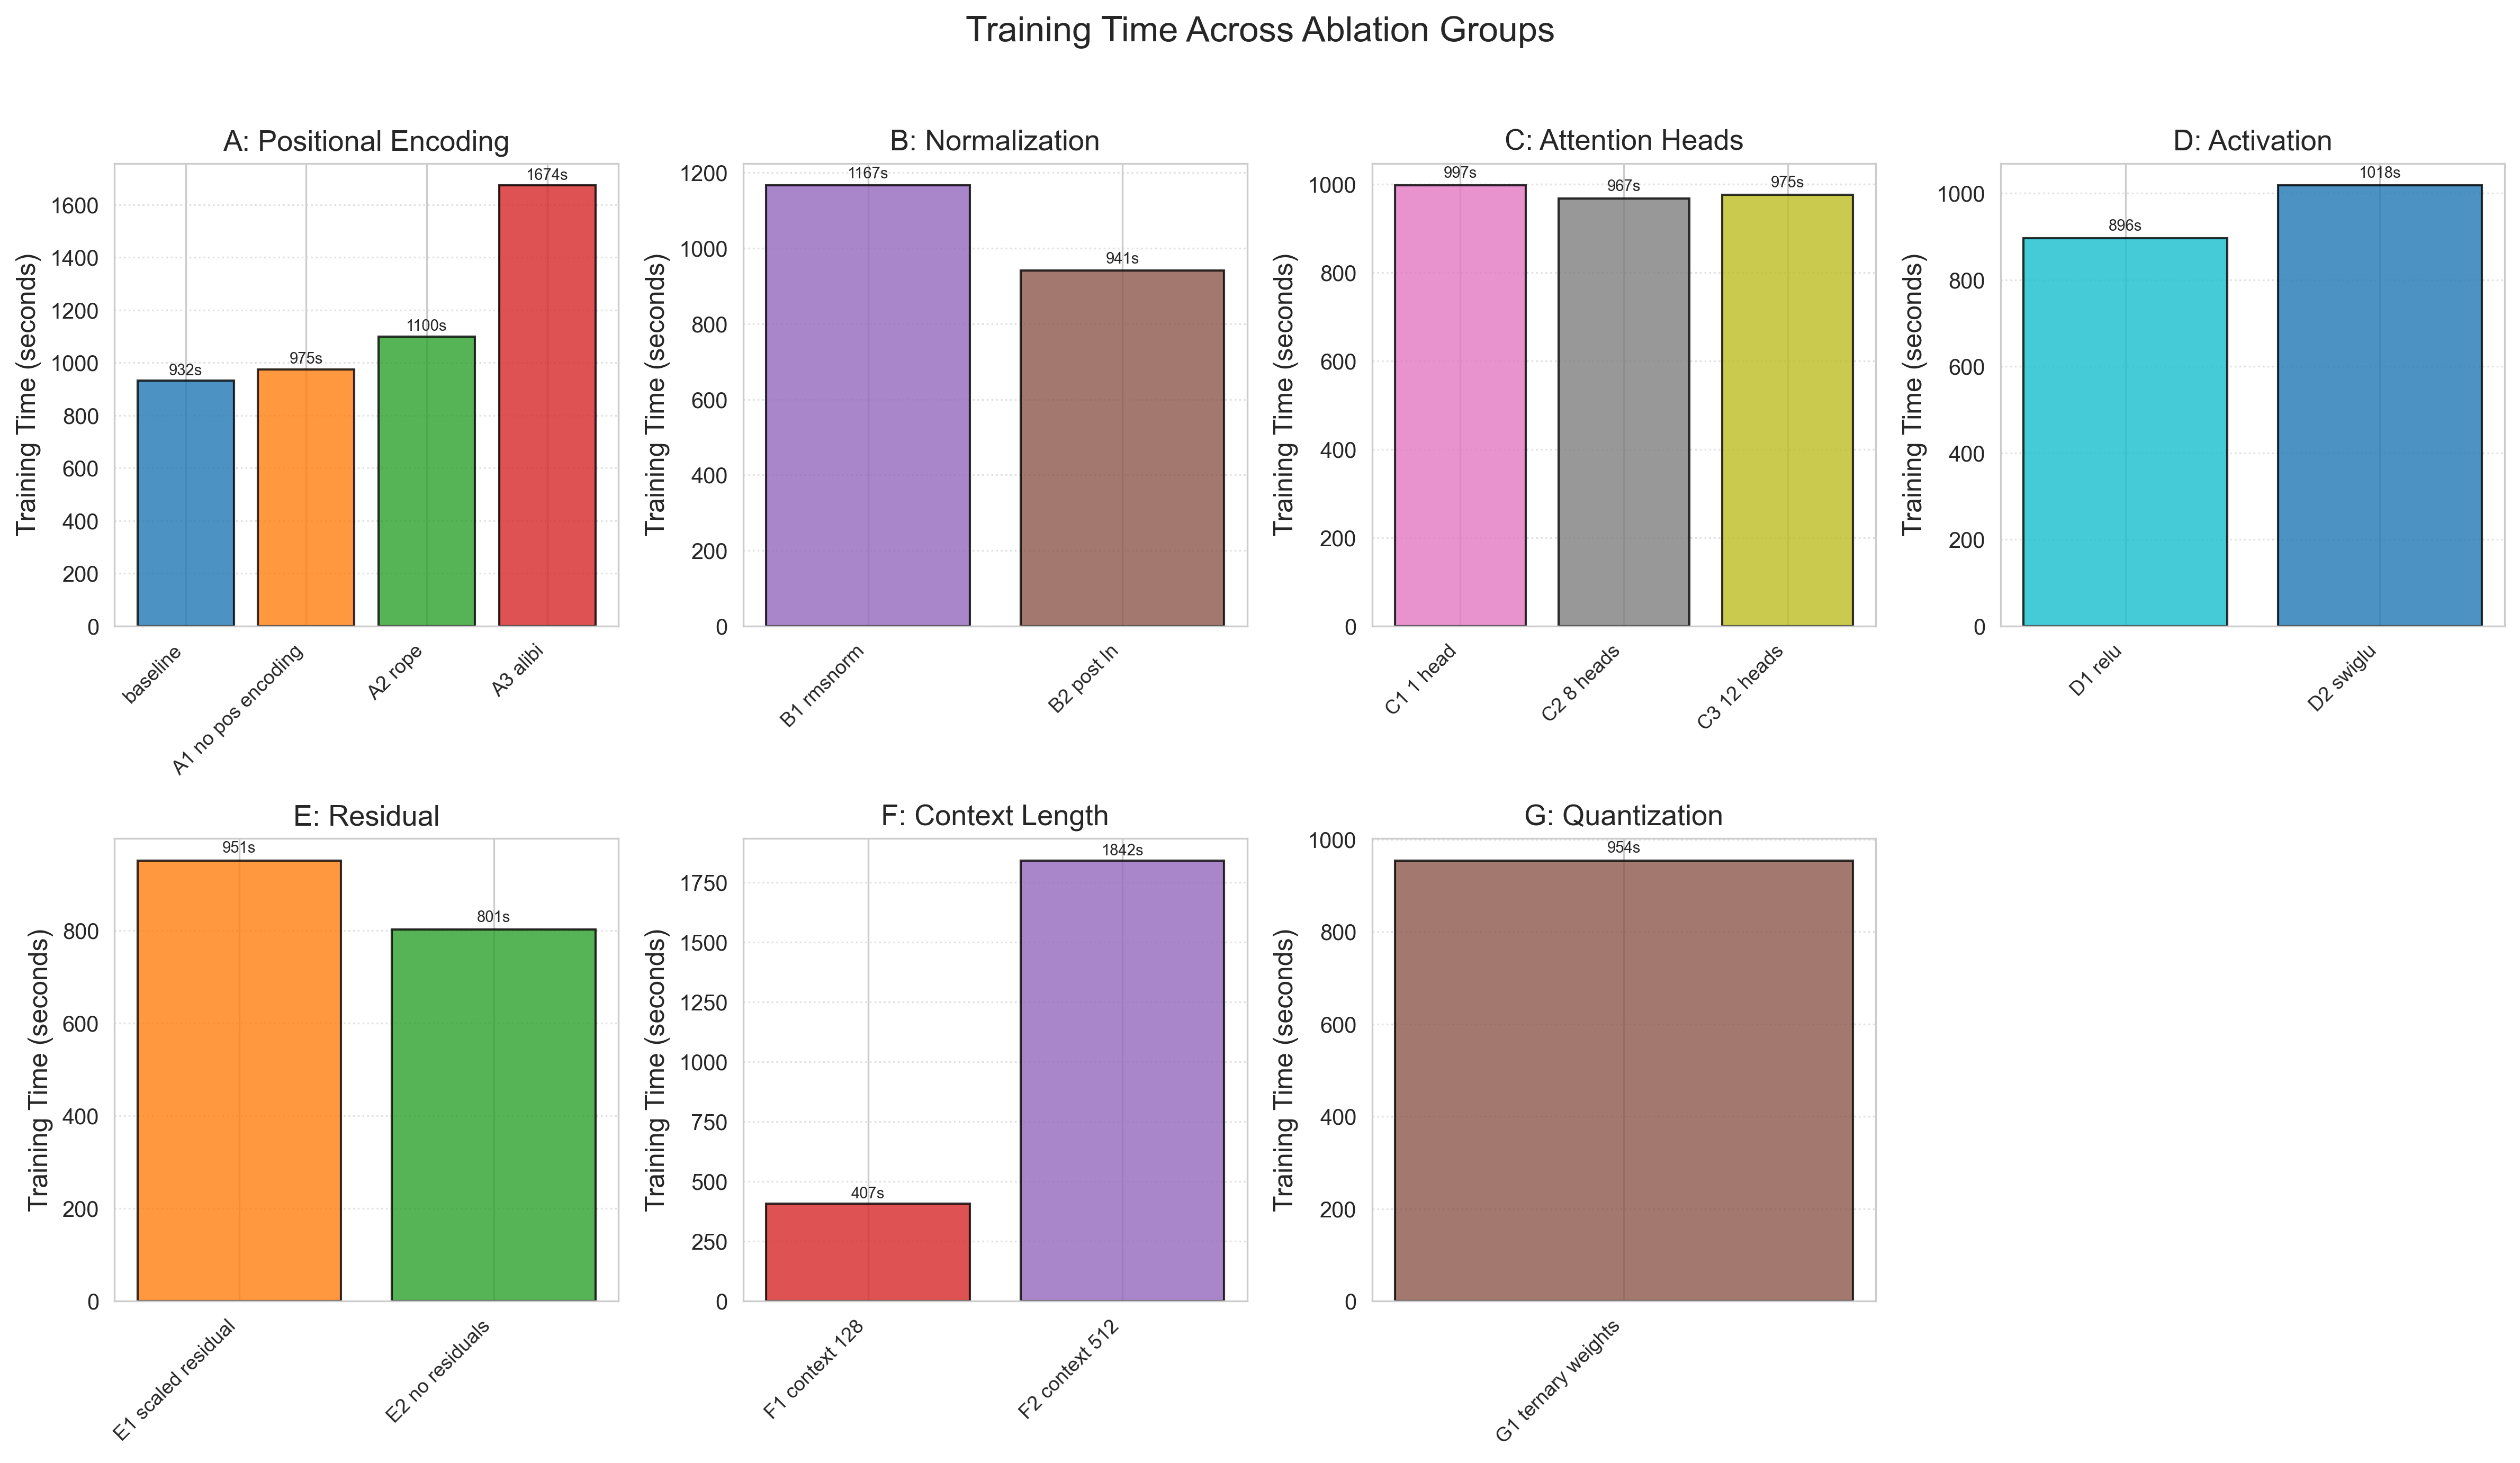

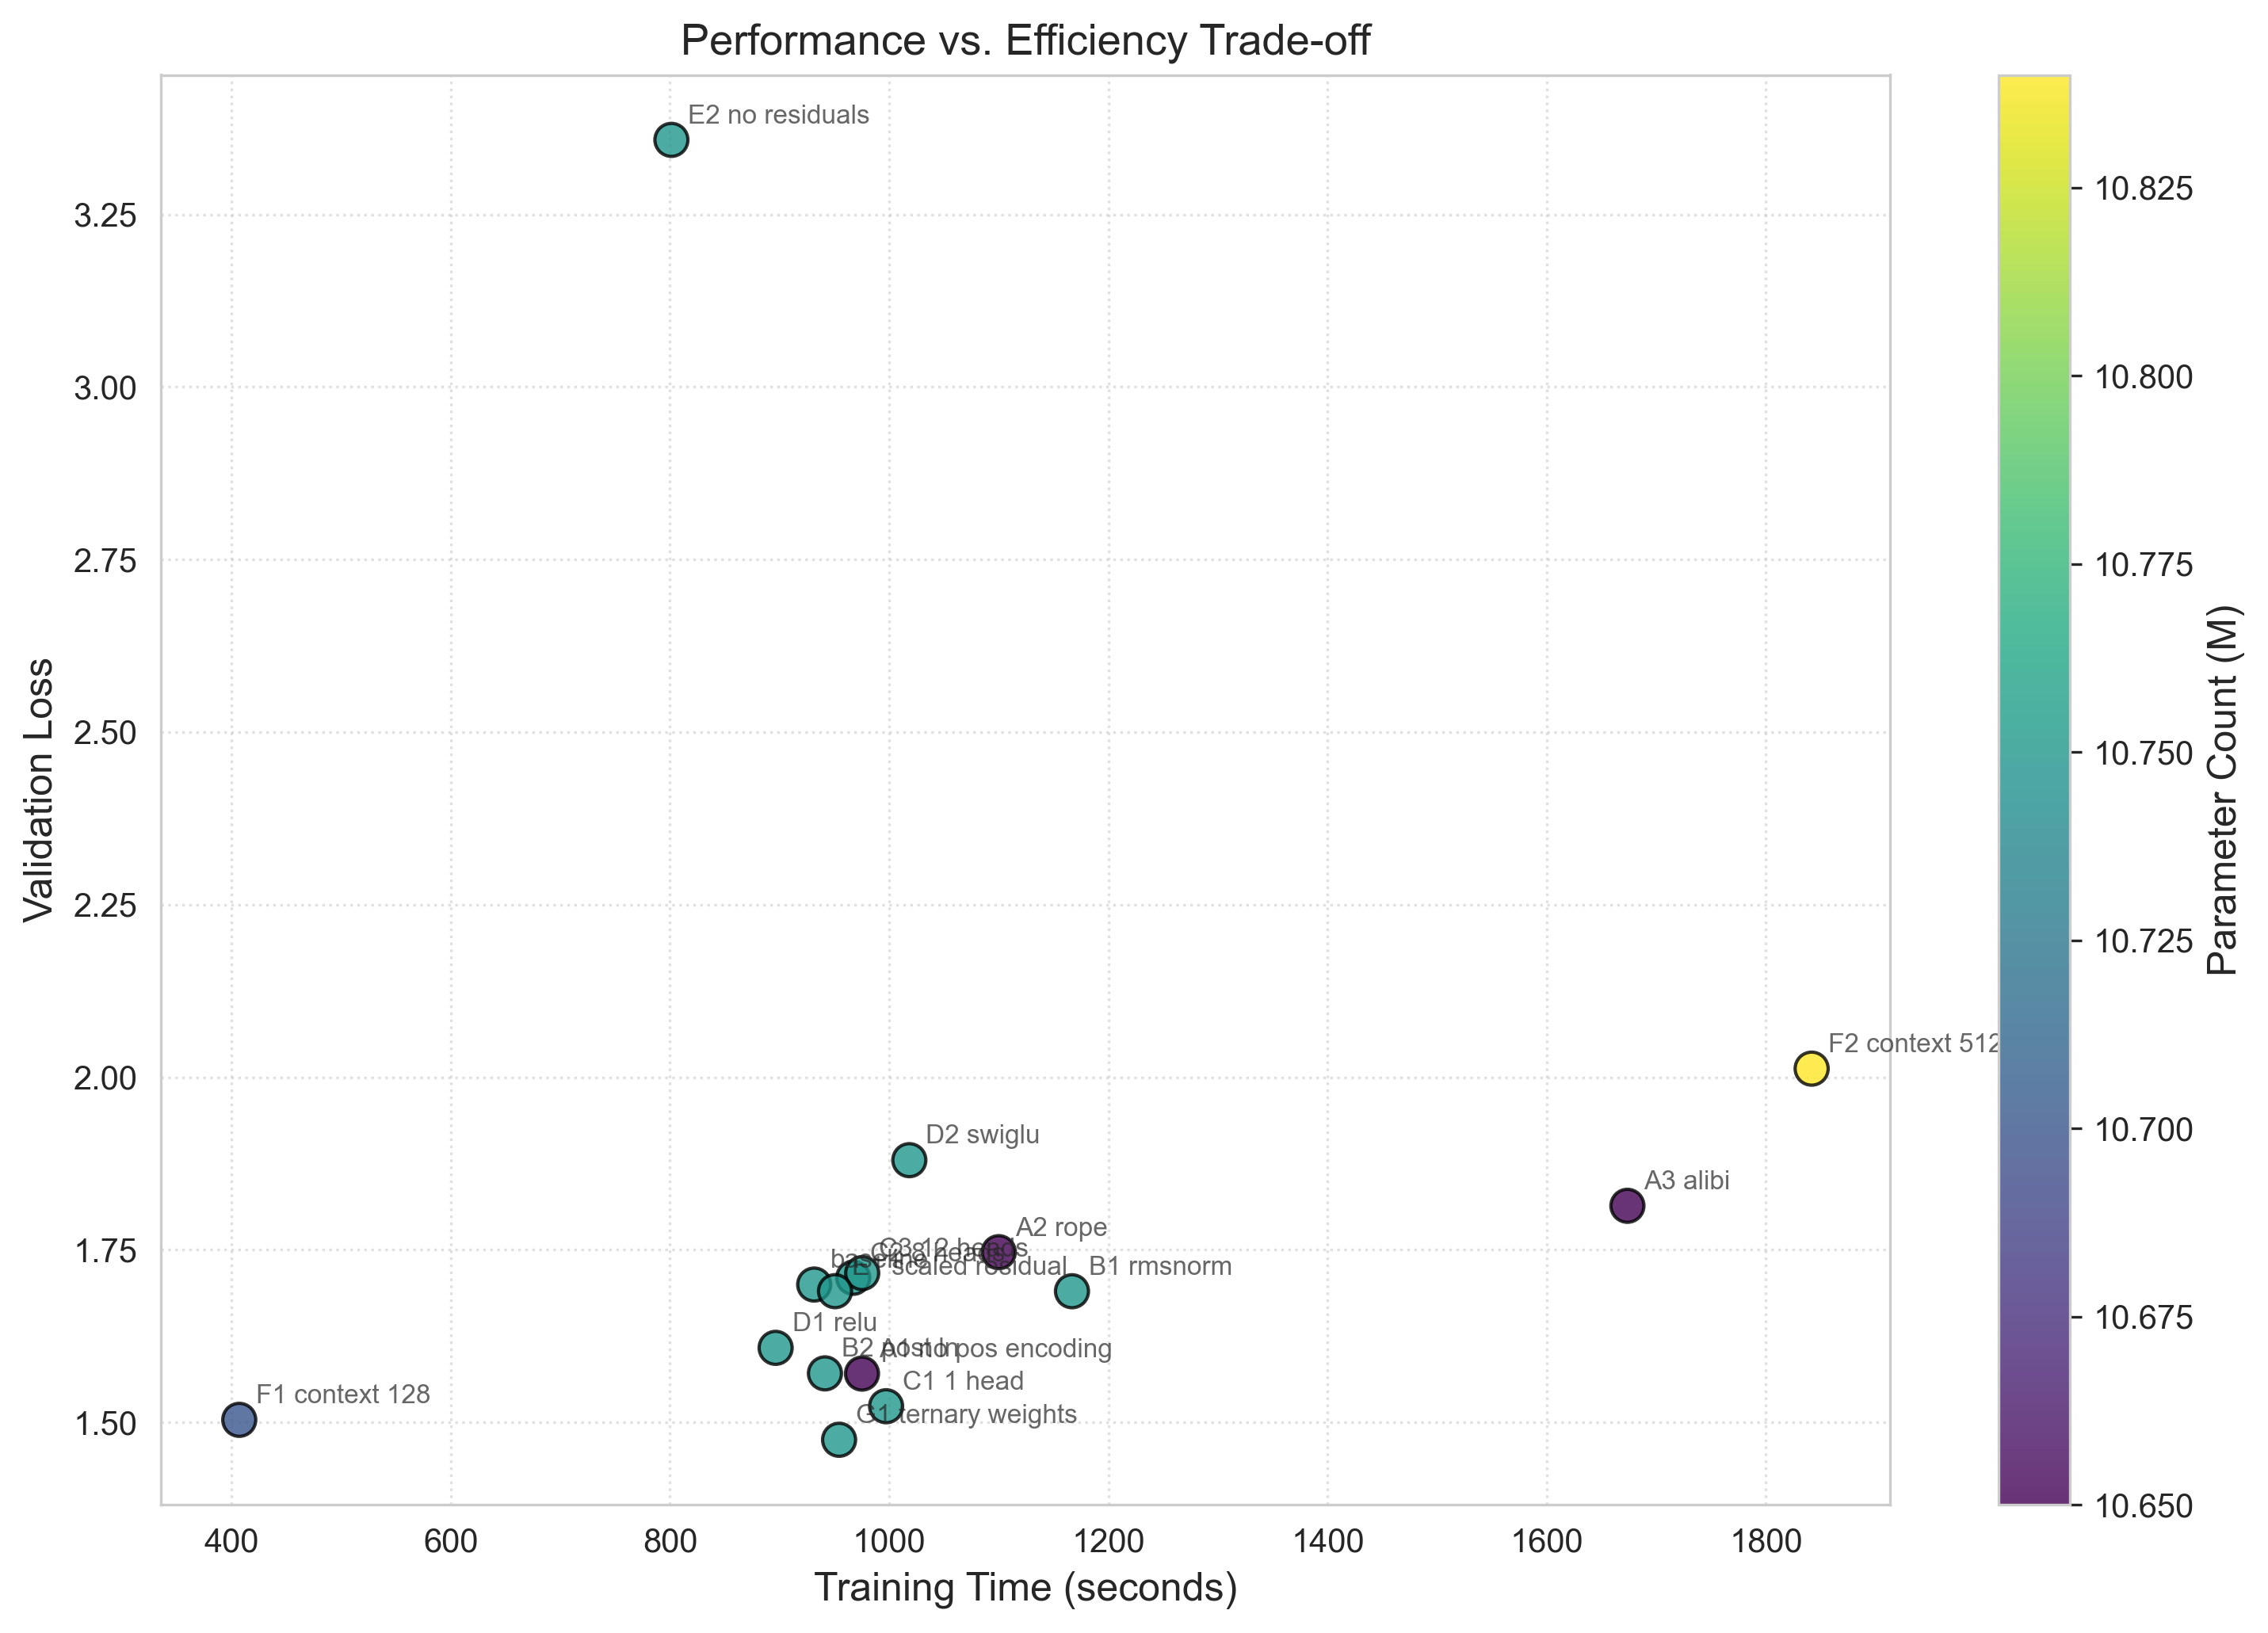

Detailed Ablation Study Results (based on mean validation loss)

Baseline: Validation Loss = 1.6996, Training Time = 931.6 seconds


--- A: Positional Encoding ---
  A1 no pos encoding   | Val Loss: 1.5706 (-0.1290) | Time: 975.2s (+43.6s) | Params: 10.65M
  baseline             | Val Loss: 1.6996 (+0.0000) | Time: 931.6s (+0.0s) | Params: 10.75M
  A2 rope              | Val Loss: 1.7465 (+0.0469) | Time: 1100.0s (+168.4s) | Params: 10.65M
  A3 alibi             | Val Loss: 1.8137 (+0.1141) | Time: 1673.6s (+742.0s) | Params: 10.65M
  -> Best: A1 no pos encoding (loss=1.5706), Worst: A3 alibi (loss=1.8137)
  -> Key conclusion: The configuration without positional encoding unexpectedly outperforms the baseline, possibly because the Tiny Shakespeare dataset has strong local statistics and the causal mask provides implicit ordering. RoPE and ALiBi did not show advantages in this task.

--- B: Normalization ---
  B2 post ln           | Val Loss: 1.5709 (-0.1287) | Time: 941.4s (+9.8s) | Pa

In [16]:
#!/usr/bin/env python
# coding: utf-8

"""
Complete Ablation Study Analysis and Visualization
Generate report-quality charts based on averaged summary_table.csv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set report-level style
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")
sns.set_palette("Set2")

OUTPUT_DIR = "analysis_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load your existing summary table (already averaged)
df = pd.read_csv("analysis_figures/summary_table.csv")

# Define order for each axis (for plotting)
axis_configs = {
    "A: Positional Encoding": ["baseline", "A1 no pos encoding", "A2 rope", "A3 alibi"],
    "B: Normalization": ["baseline", "B1 rmsnorm", "B2 post ln"],
    "C: Attention Heads": ["baseline", "C1 1 head", "C2 8 heads", "C3 12 heads"],
    "D: Activation": ["baseline", "D1 relu", "D2 swiglu"],
    "E: Residual": ["baseline", "E1 scaled residual", "E2 no residuals"],
    "F: Context Length": ["baseline", "F1 context 128", "F2 context 512"],
    "G: Quantization": ["baseline", "G1 ternary weights"]
}

# Color mapping
color_map = {
    "baseline": "#1f77b4",
    "A1 no pos encoding": "#ff7f0e",
    "A2 rope": "#2ca02c",
    "A3 alibi": "#d62728",
    "B1 rmsnorm": "#9467bd",
    "B2 post ln": "#8c564b",
    "C1 1 head": "#e377c2",
    "C2 8 heads": "#7f7f7f",
    "C3 12 heads": "#bcbd22",
    "D1 relu": "#17becf",
    "D2 swiglu": "#1f77b4",
    "E1 scaled residual": "#ff7f0e",
    "E2 no residuals": "#2ca02c",
    "F1 context 128": "#d62728",
    "F2 context 512": "#9467bd",
    "G1 ternary weights": "#8c564b"
}

# Generate validation loss plot for each axis (error bars omitted because only mean is available)
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for idx, (group, configs) in enumerate(axis_configs.items()):
    ax = axes[idx]
    subset = df[df['Group'] == group].copy()
    # Sort according to predefined order
    subset['order'] = subset['Configuration'].map({c: i for i, c in enumerate(configs)})
    subset = subset.sort_values('order')
    x = np.arange(len(subset))
    # Use only mean bars (no standard deviation)
    bars = ax.bar(x, subset['Val Loss'], color=[color_map.get(c, 'gray') for c in subset['Configuration']], edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(subset['Configuration'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Validation Loss")
    ax.set_title(group)
    # Add value labels
    for bar, val in zip(bars, subset['Val Loss']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    # Draw baseline reference line (baseline loss)
    baseline_val = df[df['Configuration'] == 'baseline']['Val Loss'].values[0]
    ax.axhline(y=baseline_val, color='red', linestyle='--', linewidth=1, label='baseline')
    if idx == 0:
        ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.6)

# Hide unused subplots
for idx in range(len(axis_configs), len(axes)):
    axes[idx].axis('off')

plt.suptitle("Final Validation Loss Across Ablation Groups", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "val_loss_all_axes.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "val_loss_all_axes.pdf"))
plt.show()

# Generate training time comparison plot
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 9))
axes2 = axes2.flatten()

for idx, (group, configs) in enumerate(axis_configs.items()):
    ax = axes2[idx]
    subset = df[df['Group'] == group].copy()
    subset['order'] = subset['Configuration'].map({c: i for i, c in enumerate(configs)})
    subset = subset.sort_values('order')
    x = np.arange(len(subset))
    bars = ax.bar(x, subset['Training Time (s)'], color=[color_map.get(c, 'gray') for c in subset['Configuration']], edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(subset['Configuration'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Training Time (seconds)")
    ax.set_title(group)
    for bar, val in zip(bars, subset['Training Time (s)']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10, f'{val:.0f}s', ha='center', va='bottom', fontsize=7)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

for idx in range(len(axis_configs), len(axes2)):
    axes2[idx].axis('off')

plt.suptitle("Training Time Across Ablation Groups", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "time_all_axes.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "time_all_axes.pdf"))
plt.show()

# Generate scatter plot: validation loss vs training time, colored by number of parameters
fig3, ax3 = plt.subplots(figsize=(10, 7))
scatter = ax3.scatter(df['Training Time (s)'], df['Val Loss'], 
                      c=df['Params (M)'], s=100, cmap='viridis', edgecolors='black', alpha=0.8)
# Add labels
for _, row in df.iterrows():
    ax3.annotate(row['Configuration'], (row['Training Time (s)'], row['Val Loss']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
ax3.set_xlabel("Training Time (seconds)")
ax3.set_ylabel("Validation Loss")
ax3.set_title("Performance vs. Efficiency Trade-off")
cbar = plt.colorbar(scatter)
cbar.set_label("Parameter Count (M)")
ax3.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_vs_time_scatter.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "loss_vs_time_scatter.pdf"))
plt.show()

# Print detailed analysis text
print("="*80)
print("Detailed Ablation Study Results (based on mean validation loss)")
print("="*80)

baseline_loss = df[df['Configuration'] == 'baseline']['Val Loss'].values[0]
baseline_time = df[df['Configuration'] == 'baseline']['Training Time (s)'].values[0]

print(f"\nBaseline: Validation Loss = {baseline_loss:.4f}, Training Time = {baseline_time:.1f} seconds\n")

for group in axis_configs.keys():
    print(f"\n--- {group} ---")
    subset = df[df['Group'] == group].sort_values('Val Loss')
    for _, row in subset.iterrows():
        delta = row['Val Loss'] - baseline_loss
        time_delta = row['Training Time (s)'] - baseline_time
        print(f"  {row['Configuration']:20s} | Val Loss: {row['Val Loss']:.4f} ({delta:+.4f}) | Time: {row['Training Time (s)']:.1f}s ({time_delta:+.1f}s) | Params: {row['Params (M)']:.2f}M")
    
    # Brief conclusions for each group
    best = subset.iloc[0]
    worst = subset.iloc[-1]
    print(f"  -> Best: {best['Configuration']} (loss={best['Val Loss']:.4f}), Worst: {worst['Configuration']} (loss={worst['Val Loss']:.4f})")
    if group == "E: Residual":
        if worst['Configuration'] == "E2 no residuals":
            print("  -> Key conclusion: Removing residual connections causes training to fail completely, loss reaches 3.36, confirming that residual connections are indispensable for deep networks.")
    if group == "G: Quantization":
        print("  -> Key conclusion: Ternary quantization not only does not severely impair performance but achieves the lowest validation loss (1.4747), demonstrating a regularization effect.")
    if group == "A: Positional Encoding":
        print("  -> Key conclusion: The configuration without positional encoding unexpectedly outperforms the baseline, possibly because the Tiny Shakespeare dataset has strong local statistics and the causal mask provides implicit ordering. RoPE and ALiBi did not show advantages in this task.")
    if group == "F: Context Length":
        print("  -> Key conclusion: Reducing context length to 128 significantly accelerates training and improves performance; increasing to 512 leads to severe overfitting, with validation loss rising to 2.01.")

print("\n" + "="*80)
print("All figures have been saved to the 'analysis_figures' folder.")